In [1]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import torch

In [2]:
words = open('Indian_Names.txt', 'r').read().splitlines()
words[:8]

['aabid', 'aabida', 'aachal', 'aadesh', 'aadil', 'aadish', 'aaditya', 'aaenab']

In [3]:
len(words)

6483

In [4]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([38124, 3]) torch.Size([38124])
torch.Size([4788, 3]) torch.Size([4788])
torch.Size([4759, 3]) torch.Size([4759])


In [6]:
#MLP revisited
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g) 
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size) ** 0.5)
# b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01 
b2 = torch.randn(vocab_size, generator=g) * 0.0

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

12097


In [7]:
lri = []
lossi = []
stepi = []
max_steps = 200000
batch_size = 32

In [8]:
for i in range(max_steps):

    #mini-batch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    #forward pass
    emb = C[Xb] #embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors

    #Linear Layer
    hpreact = embcat @ W1 # + b1 # hidden layer pre-activation

    #BatchNorm Layer
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # Non-Linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) #loss function
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if(i % 10000 == 0):
        print(f'{i:7d}/ {max_steps: 7d}: {loss.item():.4f} ')
    # stepi.append(i)
    lossi.append(loss.log10().item())

    # break
    

      0/  200000: 3.2743 
  10000/  200000: 1.8824 
  20000/  200000: 1.8652 
  30000/  200000: 2.1427 
  40000/  200000: 2.0884 
  50000/  200000: 1.8039 
  60000/  200000: 2.0692 
  70000/  200000: 2.1577 
  80000/  200000: 2.0165 
  90000/  200000: 1.7716 
 100000/  200000: 1.9712 
 110000/  200000: 1.9860 
 120000/  200000: 2.0375 
 130000/  200000: 1.7896 
 140000/  200000: 1.6553 
 150000/  200000: 1.8734 
 160000/  200000: 2.0092 
 170000/  200000: 1.9730 
 180000/  200000: 1.6380 
 190000/  200000: 1.9565 


(array([747., 279., 210., 152., 145., 141., 125., 108., 107.,  86.,  81.,
         88.,  74.,  77.,  71.,  69.,  63.,  66.,  68.,  69.,  75.,  59.,
         50.,  72.,  74.,  61.,  63.,  69.,  58.,  61.,  80.,  68.,  62.,
         77.,  80.,  75.,  78.,  68.,  86.,  82.,  96.,  97., 126., 120.,
        150., 137., 192., 214., 303., 741.]),
 array([-9.99998391e-01, -9.59998578e-01, -9.19998765e-01, -8.79998952e-01,
        -8.39999139e-01, -7.99999326e-01, -7.59999514e-01, -7.19999701e-01,
        -6.79999888e-01, -6.40000075e-01, -6.00000262e-01, -5.60000449e-01,
        -5.20000637e-01, -4.80000824e-01, -4.40001011e-01, -4.00001198e-01,
        -3.60001385e-01, -3.20001572e-01, -2.80001760e-01, -2.40001947e-01,
        -2.00002134e-01, -1.60002321e-01, -1.20002508e-01, -8.00026953e-02,
        -4.00028825e-02, -3.06963921e-06,  3.99967432e-02,  7.99965560e-02,
         1.19996369e-01,  1.59996182e-01,  1.99995995e-01,  2.39995807e-01,
         2.79995620e-01,  3.19995433e-01,  3.59995

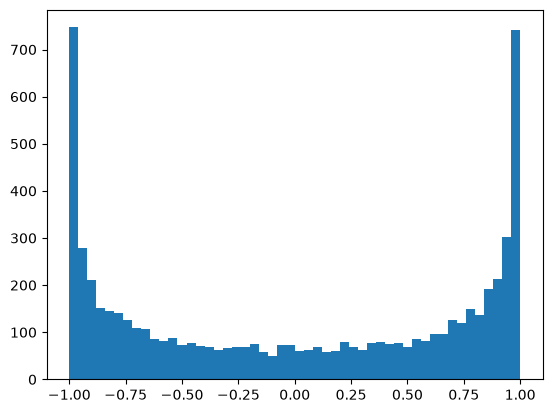

In [9]:
plt.hist(h.view(-1).tolist(), 50)

(array([  2.,   1.,   0.,   1.,   2.,   7.,   4.,   2.,   6.,  11.,  21.,
         25.,  29.,  41.,  65.,  74., 117., 141., 175., 198., 235., 270.,
        354., 378., 384., 413., 425., 422., 390., 381., 348., 317., 245.,
        215., 176., 125.,  93.,  91.,  67.,  47.,  32.,  20.,  26.,   8.,
          8.,   4.,   1.,   0.,   2.,   1.]),
 array([-7.00906706, -6.74425316, -6.47943926, -6.21462536, -5.94981146,
        -5.68499756, -5.42018366, -5.15536976, -4.89055586, -4.62574196,
        -4.36092806, -4.09611416, -3.83130026, -3.56648636, -3.30167246,
        -3.03685856, -2.77204466, -2.50723076, -2.24241686, -1.97760296,
        -1.71278906, -1.44797516, -1.18316126, -0.91834736, -0.65353346,
        -0.38871956, -0.12390566,  0.14090824,  0.40572214,  0.67053604,
         0.93534994,  1.20016384,  1.46497774,  1.72979164,  1.99460554,
         2.25941944,  2.52423334,  2.78904724,  3.05386114,  3.31867504,
         3.58348894,  3.84830284,  4.11311674,  4.37793064,  4.64274454,
 

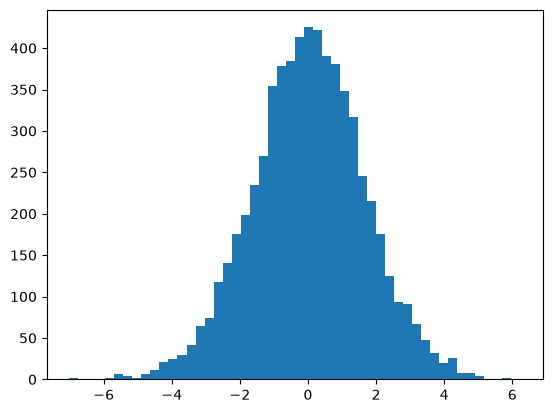

In [10]:
plt.hist(hpreact.view(-1).tolist(), 50)

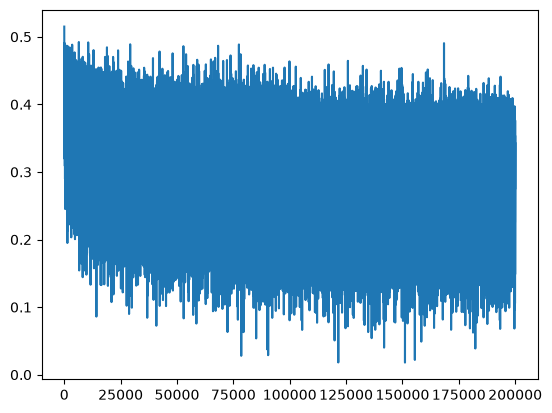

In [11]:
plt.plot(lossi)

In [13]:
# @torch.no_grad() # This decorator disables gradient tracking
# def split_loss(split):
#     x, y = {
#         'train': (Xtr, Ytr),
#         'val': (Xdev, Ydev),
#         'test': (Xte, Yte)
#     }[split]

#     emb = C[x]
#     embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
#     hpreact = embcat @ W1 + b1 # hidden layer pre-activation
#     hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    
#     h = torch.tanh(embcat @ W1 + b1)
#     logits = h @ W2 + b2
#     loss = F.cross_entropy(logits, y)
#     print(split, loss.item())
    
# split_loss('train')
# split_loss('val')    

In [15]:
# Sample from the model

g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))    

chhpalla.
brij.
khshmluu.
taz.
khslat.
kesh.
bhtlfegliratiq.
qbilllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllllrvsitpp.
suchusabbij.
zus.
zugtishetr.
karamagyover.
ksyam.
mzeshbobujinjlax.
kabfatnakshya.
luchindesh.
kovaksrinclagjalmanramsinghlao.
bhob.
bhonyi.
zem.
